### CIFAR-10 with LMU

In [ ]:
from __future__ import annotations
from typing import Dict, Any

from pathlib import Path

from cifar10_task import CIFAR10Task
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory for consistent configuration.

In [ ]:
from src.utils.block_factory import make_lmu_block_cfg_ctor

In [ ]:
from src.utils.common import device_auto

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "CIFAR10" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permute": False,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },
    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/cifar10_lmu_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 256,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

args["block_cfg_ctor"] = make_lmu_block_cfg_ctor(**args)

args = device_auto(args)

### Training
With the configuration set up, we can now instantiate the `CIFAR10Task` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [ ]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = CIFAR10Task()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

CIFAR-10 Loaders Created:
  Train: 50000 samples, 390 batches
  Test:  10000 samples, 79 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 57
Val metrics: {'loss': 0.9954345579147339, 'time_s': 15.246224583002913, 'acc': 0.6493}


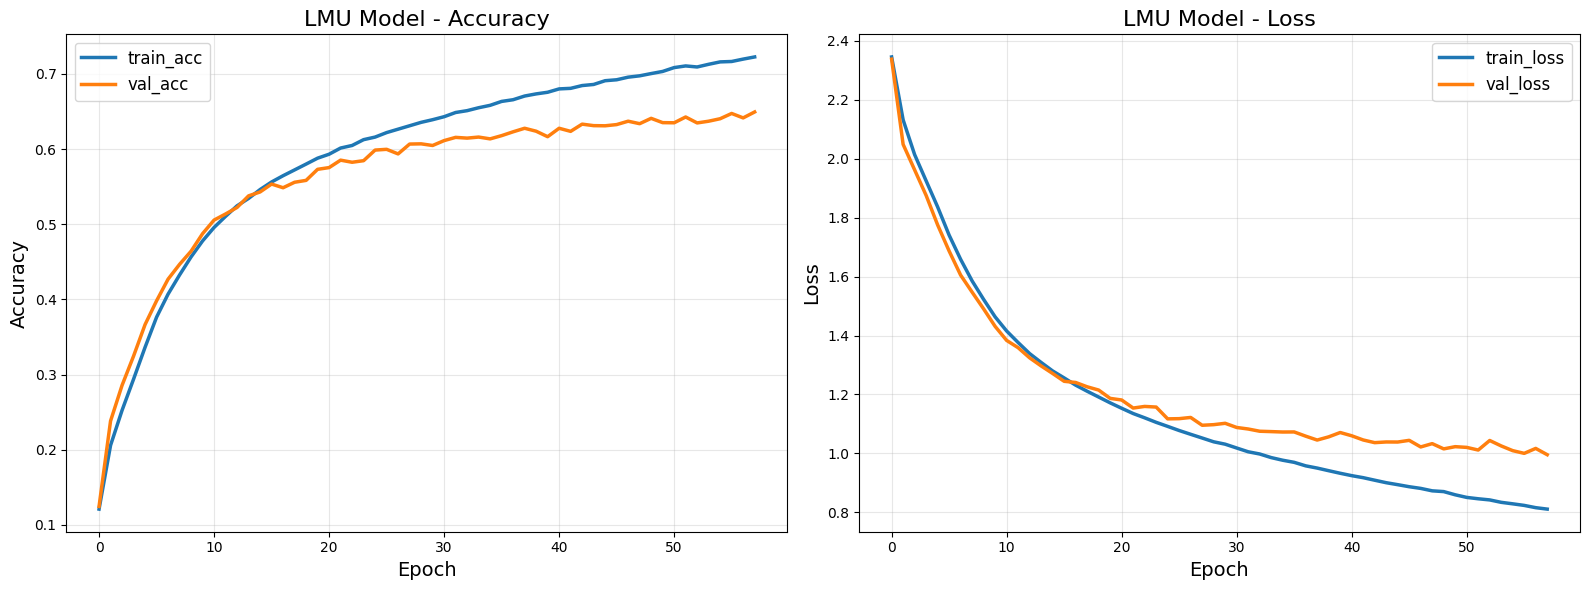

In [11]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=CIFAR10Task(),
)

history = trainer.history

plot_history(history, model_name="LMU")

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

CIFAR-10 Loaders Created:
  Train: 50000 samples, 390 batches
  Test:  10000 samples, 79 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 57
Val metrics: {'loss': 0.9954345579147339, 'time_s': 15.246224583002913, 'acc': 0.6493}
CIFAR-10 Loaders Created:
  Train: 50000 samples, 390 batches
  Test:  10000 samples, 79 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled

 Test results saved to: runs/cifar10_lmu_task/test_results.json

TEST SET RESULTS
   Accuracy: 0.6493 (64.93%)
   Loss: 0.9954
Overall accuracy: 0.6493
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_1                   : 0.792
02. class_6                   : 0.762
03. class_8                   : 0.733
04. class_7                   : 0.731
05. class_9                   : 0.697
06. class_0                   : 0.693
07. class_4                   : 0.57

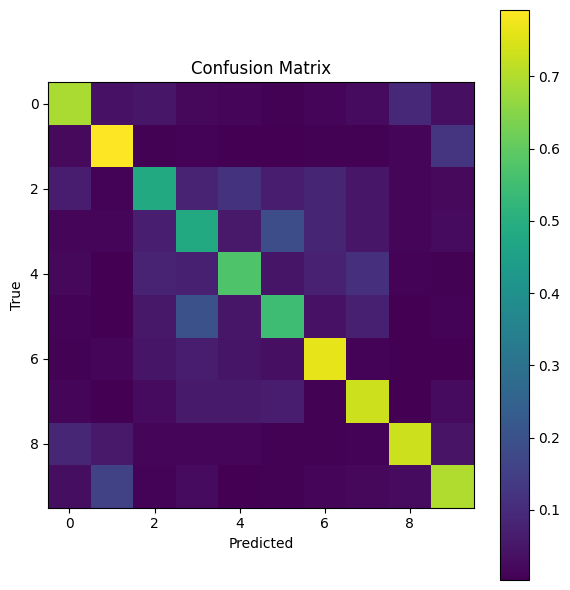

In [12]:
from src.utils.common import print_model_details
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=CIFAR10Task(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

print_model_details(model=trainer.model)

### Changes in dataset size

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/cifar10_lmu_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=CIFAR10Task())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=CIFAR10Task(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )